# Part 1: Regularization in Machine Learning

Regularization is a technique used to prevent overfitting in machine learning models by penalizing complex models. It involves adding a regularization term to the loss function to control the model's complexity.

## Types of Regularization (Self-Study)

The two most common types of regularization are L1 (Lasso) regularization and L2 (Ridge) regularization.

### L1 Regularization - Lasso

L1 regularization adds the sum of the absolute values of the coefficients to the loss function. It can lead to sparse models where some feature coefficients are zeroed out, effectively performing feature selection.

$$ \text{Loss Function} = \text{MSE} + \alpha \sum_{i=1}^{n} |w_i| $$

### L2 Regularization - Ridge

L2 regularization adds the sum of the squares of the coefficients to the loss function. It doesn't zero out coefficients but ensures they are small, leading to a less complex model.

$$ \text{Loss Function} = \text{MSE} + \alpha \sum_{i=1}^{n} w_i^2 $$

### Elastic Net

Elastic Net is a combination of L1 and L2 regularization. It is useful when there are multiple correlated features.

$$ \text{Loss Function} = \text{MSE} + \alpha \rho \sum_{i=1}^{n} |w_i| + \alpha (1-\rho) \sum_{i=1}^{n} w_i^2 $$

### Choosing the Regularization Parameter

The regularization parameter ($\alpha$) controls the strength of the penalty. The L1 ratio ($\rho$) controls the combination of L1 and L2 penalties.

**Benefits of Regularization**

- Reduces overfitting by penalizing large coefficients.
- Can lead to simpler models that generalize better.
- In the case of L1 regularization, can perform feature selection by zeroing out coefficients.

# Model: Linear Regression Hands-On

In [29]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.datasets import make_regression, make_classification

In [17]:
# Set the PD dataframe to show all the columns instead of ignoring some of them
pd.set_option('display.max_columns', None)

In [1]:
## 1. Load the dataset, and check the stats of the data
# Load csv file by pandas,the dataset is in ../assets/data.csv
import pandas as pd
data = pd.read_csv('../assets/data.csv')
print(data.head())
print(data.info())
print(data.describe())


   yearID teamID    G    R    AB     H   2B  3B   HR   BB  ...  decade_1970  \
0    1935    BOS  154  718  5288  1458  281  63   69  609  ...        False   
1    1993    TEX  162  835  5510  1472  284  39  181  483  ...        False   
2    2016    SEA  162  768  5583  1446  251  17  223  506  ...        False   
3    1938    CHN  154  713  5333  1435  242  70   65  522  ...        False   
4    1996    BOS  162  928  5756  1631  308  31  209  642  ...        False   

   decade_1980  decade_1990  decade_2000  decade_2010   W    ID  year_label  \
0        False        False        False        False  78   317        1935   
1        False         True        False        False  86  2162        1993   
2        False        False        False         True  86  1895        2016   
3        False        False        False        False  89   428        1938   
4        False         True        False        False  85   375        1996   

   decade_label  win_bins  
0         1930s       

In [12]:
data

,yearID,teamID,G,R,AB,H,2B,3B,HR,BB,SO,SB,RA,ER,ERA,CG,SHO,SV,IPouts,HA,HRA,BBA,SOA,E,DP,FP,mlb_rpg,era_1,era_2,era_3,era_4,era_5,era_6,era_7,era_8,decade_1910,decade_1920,decade_1930,decade_1940,decade_1950,decade_1960,decade_1970,decade_1980,decade_1990,decade_2000,decade_2010,W,ID,year_label,decade_label,win_bins,Run_Diff,R_per_game,RA_per_game,OPS_like,Power_Index,Plate_Discipline_Index
0,1935,BOS,154,718,5288,1458,281,63,69,609,470.0,91,732,619,4.05,82,6,11,4128,1520,67,520,470,190,136.0,0.969,4.864690,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,78,317,1935,1930s,3,-14,4.662338,4.753247,0.403933,259.9,1.295745
1,1993,TEX,162,835,5510,1472,284,39,181,483,984.0,113,751,684,4.28,20,6,45,4314,1476,144,562,957,130,145.0,0.979,4.597620,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,86,2162,1993,1990s,3,84,5.154321,4.635802,0.387659,354.2,0.490854
2,2016,SEA,162,768,5583,1446,251,17,223,506,1288.0,56,707,647,4.00,2,8,49,4371,1410,213,460,1318,89,158.0,0.985,4.477759,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,86,1895,2016,2010s,3,61,4.740741,4.364198,0.389575,362.1,0.392857
3,1938,CHN,154,713,5333,1435,242,70,65,522,476.0,49,598,523,3.37,67,16,18,4188,1414,71,454,583,135,151.0,0.978,4.902046,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,89,428,1938,1930s,3,115,4.629870,3.883117,0.379149,242.0,1.096639
4,1996,BOS,162,928,5756,1631,308,31,209,642,1020.0,91,921,810,5.00,17,5,37,4374,1606,185,722,1165,135,152.0,0.978,5.035509,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,85,375,1996,1990s,3,7,5.728395,5.685185,0.431202,387.8,0.629412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807,1947,PHI,155,589,5256,1354,210,52,60,464,594.0,60,687,599,3.96,70,8,14,4086,1399,98,513,514,152,140.0,0.974,4.355189,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,62,1639,1947,1940s,2,-98,3.800000,4.432258,0.357306,206.6,0.781145
1808,1928,BRO,155,665,5243,1393,229,70,66,557,510.0,81,640,504,3.25,75,16,15,4188,1378,59,468,551,217,113.0,0.965,4.729894,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,77,1096,1928,1920s,3,25,4.290323,4.129032,0.384513,236.5,1.092157
1809,1963,LAN,163,640,5428,1361,178,34,110,453,867.0,124,550,465,2.85,51,24,29,4407,1329,111,402,1095,158,129.0,0.975,3.946881,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,99,1131,1963,1960s,4,90,3.926380,3.374233,0.354458,226.2,0.522491
1810,1974,MIN,163,673,5632,1530,190,37,111,520,791.0,74,669,588,3.64,43,11,29,4365,1436,115,513,934,151,164.0,0.976,4.124936,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,82,1295,1974,1970s,3,4,4.128834,4.104294,0.383700,235.6,0.657396


In [19]:
# Feature 1: construct a new feature Run_Diff through feature R and RA in dataset, formula is Run_Diff = R - RA
data['Run_Diff_1'] = data['R'] - data['RA']

# Feature 2 and 3: construct Runs Scored & Allowed per game, through feature R and RA in dataset, formula is R_per_game = R / G, RA_per_game = RA / G
data['R_per_game_2'] = data['R'] / data['G']
data['RA_per_game_3'] = data['RA'] / data['G']

# Feasure 4: construct OPS-like Feature, through feature H, AB, HR, BB, HBP in dataset, formula is OPS_like = (H + BB + HBP) / (AB + BB + HBP)
data['OPS_like_3'] = (data['H'] + data['BB'] + data['HR']) / data['AB'] 

# Feature 5: construct Power Index, through feature HR and AB in dataset, formula is Power_Index = HR + 0.5 * 2B + 0.8 * 3B
data['Power_Index_4'] = data['HR'] + 0.5 * data['2B'] + 0.8 * data['3B']

# Feature 6: construct Plate Discipline Index, through feature BB and SO in dataset, formula is Plate_Discipline_Index = BB / SO
data['Plate_Discipline_Index_5'] = data['BB'] / data['SO']

# Feature 7: construct WHIP-like Feature, through feature H, BB, and IP in dataset, formula is WHIP_like = (HA + BBA) / IP
data['WHIP_like_6'] = (data['HA'] + data['BBA']) / data['IPouts']

# Feature 8: construct Strikeout Control index by K_BB_ratio = SOA/BBA
data['K_BB_ratio_7'] = data['SOA'] / data['BBA']

# Feature 9: construct a new fearue naming Home Run Supression by HR_allowed_rate = HRA / IP
data['HR_allowed_rate_8'] = data['HRA'] / data['IPouts']

# Feature 10: construct Fielding Efficiency by Defence = FP - (E /Games)
data['Defence_10'] = data['FP'] - (data['E'] / data['G'])

data

,yearID,teamID,G,R,AB,H,2B,3B,HR,BB,SO,SB,RA,ER,ERA,CG,SHO,SV,IPouts,HA,HRA,BBA,SOA,E,DP,FP,mlb_rpg,era_1,era_2,era_3,era_4,era_5,era_6,era_7,era_8,decade_1910,decade_1920,decade_1930,decade_1940,decade_1950,decade_1960,decade_1970,decade_1980,decade_1990,decade_2000,decade_2010,W,ID,year_label,decade_label,win_bins,Run_Diff,R_per_game,RA_per_game,OPS_like,Power_Index,Plate_Discipline_Index,WHIP_like,K_BB_ratio,HR_allowed_rate,Defence,Run_Diff_1,R_per_game_2,RA_per_game_3,OPS_like_3,Power_Index_4,Plate_Discipline_Index_5,WHIP_like_6,K_BB_ratio_7,HR_allowed_rate_8,Defence_10
0,1935,BOS,154,718,5288,1458,281,63,69,609,470.0,91,732,619,4.05,82,6,11,4128,1520,67,520,470,190,136.0,0.969,4.864690,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,78,317,1935,1930s,3,-14,4.662338,4.753247,0.403933,259.9,1.295745,0.494186,0.903846,0.016231,-0.264766,-14,4.662338,4.753247,0.403933,259.9,1.295745,0.494186,0.903846,0.016231,-0.264766
1,1993,TEX,162,835,5510,1472,284,39,181,483,984.0,113,751,684,4.28,20,6,45,4314,1476,144,562,957,130,145.0,0.979,4.597620,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,86,2162,1993,1990s,3,84,5.154321,4.635802,0.387659,354.2,0.490854,0.472415,1.702847,0.033380,0.176531,84,5.154321,4.635802,0.387659,354.2,0.490854,0.472415,1.702847,0.033380,0.176531
2,2016,SEA,162,768,5583,1446,251,17,223,506,1288.0,56,707,647,4.00,2,8,49,4371,1410,213,460,1318,89,158.0,0.985,4.477759,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,86,1895,2016,2010s,3,61,4.740741,4.364198,0.389575,362.1,0.392857,0.427820,2.865217,0.048730,0.435617,61,4.740741,4.364198,0.389575,362.1,0.392857,0.427820,2.865217,0.048730,0.435617
3,1938,CHN,154,713,5333,1435,242,70,65,522,476.0,49,598,523,3.37,67,16,18,4188,1414,71,454,583,135,151.0,0.978,4.902046,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,89,428,1938,1930s,3,115,4.629870,3.883117,0.379149,242.0,1.096639,0.446036,1.284141,0.016953,0.101377,115,4.629870,3.883117,0.379149,242.0,1.096639,0.446036,1.284141,0.016953,0.101377
4,1996,BOS,162,928,5756,1631,308,31,209,642,1020.0,91,921,810,5.00,17,5,37,4374,1606,185,722,1165,135,152.0,0.978,5.035509,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,85,375,1996,1990s,3,7,5.728395,5.685185,0.431202,387.8,0.629412,0.532236,1.613573,0.042295,0.144667,7,5.728395,5.685185,0.431202,387.8,0.629412,0.532236,1.613573,0.042295,0.144667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807,1947,PHI,155,589,5256,1354,210,52,60,464,594.0,60,687,599,3.96,70,8,14,4086,1399,98,513,514,152,140.0,0.974,4.355189,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,62,1639,1947,1940s,2,-98,3.800000,4.432258,0.357306,206.6,0.781145,0.467939,1.001949,0.023984,-0.006645,-98,3.800000,4.432258,0.357306,206.6,0.781145,0.467939,1.001949,0.023984,-0.006645
1808,1928,BRO,155,665,5243,1393,229,70,66,557,510.0,81,640,504,3.25,75,16,15,4188,1378,59,468,551,217,113.0,0.965,4.729894,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,77,1096,1928,1920s,3,25,4.290323,4.129032,0.384513,236.5,1.092157,0.440783,1.177350,0.014088,-0.435000,25,4.290323,4.129032,0.384513,236.5,1.092157,0.440783,1.177350,0.014088,-0.435000
1809,1963,LAN,163,640,5428,1361,178,34,110,453,867.0,124,550,465,2.85,51,24,29,4407,1329,111,402,1095,158,129.0,0.975,3.946881,False,False,False,False,True,False,False,False,False,False,False,False,False,True,

In [20]:
# Drop out the YearID, TeamID, ID, era-like features, YearLabel like features, DecadeLabel like features and Win Bins from the dataset, and set the target variable as 'W', and the rest of the features as the input features.
# axis = 0 means moving vertically to drop the row, and axis = 1 means moving horizontally to drop the column.
X = data.drop(['yearID', 'teamID', 'ID', 'year_label', 'decade_label', 'win_bins', 'W', 'era_1', 'era_2', 'era_3', 'era_4', 'era_5', 'era_6', 'era_7', 'era_8', 'decade_1910', 'decade_1920', 'decade_1930', 'decade_1940', 'decade_1950', 'decade_1960', 'decade_1970', 'decade_1980', 'decade_1990', 'decade_2000', 'decade_2010'], axis=1)
y = data['W']
X

,G,R,AB,H,2B,3B,HR,BB,SO,SB,RA,ER,ERA,CG,SHO,SV,IPouts,HA,HRA,BBA,SOA,E,DP,FP,mlb_rpg,Run_Diff,R_per_game,RA_per_game,OPS_like,Power_Index,Plate_Discipline_Index,WHIP_like,K_BB_ratio,HR_allowed_rate,Defence,Run_Diff_1,R_per_game_2,RA_per_game_3,OPS_like_3,Power_Index_4,Plate_Discipline_Index_5,WHIP_like_6,K_BB_ratio_7,HR_allowed_rate_8,Defence_10
0,154,718,5288,1458,281,63,69,609,470.0,91,732,619,4.05,82,6,11,4128,1520,67,520,470,190,136.0,0.969,4.864690,-14,4.662338,4.753247,0.403933,259.9,1.295745,0.494186,0.903846,0.016231,-0.264766,-14,4.662338,4.753247,0.403933,259.9,1.295745,0.494186,0.903846,0.016231,-0.264766
1,162,835,5510,1472,284,39,181,483,984.0,113,751,684,4.28,20,6,45,4314,1476,144,562,957,130,145.0,0.979,4.597620,84,5.154321,4.635802,0.387659,354.2,0.490854,0.472415,1.702847,0.033380,0.176531,84,5.154321,4.635802,0.387659,354.2,0.490854,0.472415,1.702847,0.033380,0.176531
2,162,768,5583,1446,251,17,223,506,1288.0,56,707,647,4.00,2,8,49,4371,1410,213,460,1318,89,158.0,0.985,4.477759,61,4.740741,4.364198,0.389575,362.1,0.392857,0.427820,2.865217,0.048730,0.435617,61,4.740741,4.364198,0.389575,362.1,0.392857,0.427820,2.865217,0.048730,0.435617
3,154,713,5333,1435,242,70,65,522,476.0,49,598,523,3.37,67,16,18,4188,1414,71,454,583,135,151.0,0.978,4.902046,115,4.629870,3.883117,0.379149,242.0,1.096639,0.446036,1.284141,0.016953,0.101377,115,4.629870,3.883117,0.379149,242.0,1.096639,0.446036,1.284141,0.016953,0.101377
4,162,928,5756,1631,308,31,209,642,1020.0,91,921,810,5.00,17,5,37,4374,1606,185,722,1165,135,152.0,0.978,5.035509,7,5.728395,5.685185,0.431202,387.8,0.629412,0.532236,1.613573,0.042295,0.144667,7,5.728395,5.685185,0.431202,387.8,0.629412,0.532236,1.613573,0.042295,0.144667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807,155,589,5256,1354,210,52,60,464,594.0,60,687,599,3.96,70,8,14,4086,1399,98,513,514,152,140.0,0.974,4.355189,-98,3.800000,4.432258,0.357306,206.6,0.781145,0.467939,1.001949,0.023984,-0.006645,-98,3.800000,4.432258,0.357306,206.6,0.781145,0.467939,1.001949,0.023984,-0.006645
1808,155,665,5243,1393,229,70,66,557,510.0,81,640,504,3.25,75,16,15,4188,1378,59,468,551,217,113.0,0.965,4.729894,25,4.290323,4.129032,0.384513,236.5,1.092157,0.440783,1.177350,0.014088,-0.435000,25,4.290323,4.129032,0.384513,236.5,1.092157,0.440783,1.177350,0.014088,-0.435000
1809,163,640,5428,1361,178,34,110,453,867.0,124,550,465,2.85,51,24,29,4407,1329,111,402,1095,158,129.0,0.975,3.946881,90,3.926380,3.374233,0.354458,226.2,0.522491,0.392784,2.723881,0.025187,0.005675,90,3.926380,3.374233,0.354458,226.2,0.522491,0.392784,2.723881,0.025187,0.005675
1810,163,673,5632,1530,190,37,111,520,791.0,74,669,588,3.64,43,11,29,4365,1436,115,513,934,151,164.0,0.976,4.124936,4,4.128834,4.104294,0.383700,235.6,0.657396,0.446506,1.820663,0.026346,0.049620,4,4.128834,4.104294,0.383700,235.6,0.657396,0.446506,1.820663,0.026346,0.049620


In [21]:
# Select all the new 10 features as REAL features and show the data again
X = data[['Run_Diff_1', 'R_per_game_2', 'RA_per_game_3', 'OPS_like_3', 'Power_Index_4', 'Plate_Discipline_Index_5', 'WHIP_like_6', 'K_BB_ratio_7', 'HR_allowed_rate_8', 'Defence_10']]
X

,Run_Diff_1,R_per_game_2,RA_per_game_3,OPS_like_3,Power_Index_4,Plate_Discipline_Index_5,WHIP_like_6,K_BB_ratio_7,HR_allowed_rate_8,Defence_10
0,-14,4.662338,4.753247,0.403933,259.9,1.295745,0.494186,0.903846,0.016231,-0.264766
1,84,5.154321,4.635802,0.387659,354.2,0.490854,0.472415,1.702847,0.033380,0.176531
2,61,4.740741,4.364198,0.389575,362.1,0.392857,0.427820,2.865217,0.048730,0.435617
3,115,4.629870,3.883117,0.379149,242.0,1.096639,0.446036,1.284141,0.016953,0.101377
4,7,5.728395,5.685185,0.431202,387.8,0.629412,0.532236,1.613573,0.042295,0.144667
...,...,...,...,...,...,...,...,...,...,...
1807,-98,3.800000,4.432258,0.357306,206.6,0.781145,0.467939,1.001949,0.023984,-0.006645
1808,25,4.290323,4.129032,0.384513,236.5,1.092157,0.440783,1.177350,0.014088,-0.435000
1809,90,3.926380,3.374233,0.354458,226.2,0.522491,0.392784,2.723881,0.025187,0.005675
1810,4,4.128834,4.104294,0.383700,235.6,0.657396,0.446506,1.820663,0.026346,0.049620


In [22]:
# Check whether there is any null value in the dataset, if there is, fill the null value with the mean value of the column
print(X.isnull().sum())
X = X.fillna(X.mean())
print(X.isnull().sum())

Run_Diff_1                  0
R_per_game_2                0
RA_per_game_3               0
OPS_like_3                  0
Power_Index_4               0
Plate_Discipline_Index_5    0
WHIP_like_6                 0
K_BB_ratio_7                0
HR_allowed_rate_8           0
Defence_10                  0
dtype: int64
Run_Diff_1                  0
R_per_game_2                0
RA_per_game_3               0
OPS_like_3                  0
Power_Index_4               0
Plate_Discipline_Index_5    0
WHIP_like_6                 0
K_BB_ratio_7                0
HR_allowed_rate_8           0
Defence_10                  0
dtype: int64


In [24]:
# Finaly check the features and target variable again
print(X.head())
print(X.shape)
print(y.head())
print(y.shape)

   Run_Diff_1  R_per_game_2  RA_per_game_3  OPS_like_3  Power_Index_4  \
0         -14      4.662338       4.753247    0.403933          259.9   
1          84      5.154321       4.635802    0.387659          354.2   
2          61      4.740741       4.364198    0.389575          362.1   
3         115      4.629870       3.883117    0.379149          242.0   
4           7      5.728395       5.685185    0.431202          387.8   

   Plate_Discipline_Index_5  WHIP_like_6  K_BB_ratio_7  HR_allowed_rate_8  \
0                  1.295745     0.494186      0.903846           0.016231   
1                  0.490854     0.472415      1.702847           0.033380   
2                  0.392857     0.427820      2.865217           0.048730   
3                  1.096639     0.446036      1.284141           0.016953   
4                  0.629412     0.532236      1.613573           0.042295   

   Defence_10  
0   -0.264766  
1    0.176531  
2    0.435617  
3    0.101377  
4    0.144667  
(1

In [ ]:
## 2. Preprocess the data (handle missing values, encode categorical variables, feature scaling)
# Has completed in the above

In [30]:
## 3. Define the model (1) Linear Regression, Ridge Regression, Random Forest for regression, Decision Tree for Regression)
# First, split the above X and Y into training and testing sets, with 80% of the data for training and 20% for testing, and set the random state to 42 for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Linear Regression model
linear_model = LinearRegression()
# Fit the model to the training data
linear_model.fit(X_train, y_train)
# Predict the target variable for the test set
y_pred_linear = linear_model.predict(X_test)
# Evaluate the model using Mean Squared Error
mse_linear = mean_squared_error(y_test, y_pred_linear)
print(f'Linear Regression MSE: {mse_linear}')

# Evaluate the model using RMSE
#rmse_linear = mean_squared_error(y_test, y_pred_linear, squared=False)
rmse_linear = np.sqrt(mse_linear)
print(f'Linear Regression RMSE: {rmse_linear}')

# Calculate the R-squared value for the Linear Regression model
r_squared_linear = linear_model.score(X_test, y_test)
print(f'Linear Regression R-squared: {r_squared_linear}')






Linear Regression MSE: 19.064517768433003
Linear Regression RMSE: 4.366293367197514
Linear Regression R-squared: 0.8812665848632898


In [34]:
# print the predicted values in integer and the actual values for the test set, and calculate the difference in percentage with only 2 decimal places
print('Predicted values:', y_pred_linear.astype(int))
print('Actual values:', y_test.values)

# Calculate the difference in percentage
difference_percentage = ((y_pred_linear.astype(int) - y_test.values) / y_test.values * 100).round(2)
print('Difference in percentage:', difference_percentage)

Predicted values: [ 77  76  82  87  78  63  76  61  59  66  80  77  90  78  79  95  87  87
  59  92  95 102  69  79  84 102  59  61  72  61  88  96  70  87  78  78
  48  83  87  74  96  56  94  85  88  88  87  75  54  74  83  91  66  90
  87  71  85  78  85  80  88  97  75  60  72  55  93  83  85  98  83  79
  75  62  68  88  61  90  72  67  81  81  81  60  90  85  76  76  79  63
  67  65  61  80  47  67  68  90  71  88  84  98  92  72  63  49  51  94
  58  90  88  80  97  79  68  71  48  83  84  95  83  87  84  79  88  92
  84  94  73  85  78 102  91  96  80  86  63  69  64  83  65  88  86  91
  94  79  95  93  64  79  92  75  94  76  81  69  49  87  68  89  75 100
 100  62  83 103  84  65  67  62  88  72  76  52  86  80  75  84  91  85
  73  67  91  79  73  70  70  76  64 103  80  78  86  74  83  82  86  94
  71  73  95  75  93  73  91  67  78  91  68  67  97  67  98  94  69  76
  93  71  77  70  69  80  70  69  93  69  88  67  94  81  84  62  78  89
  72  69  94  80  51  85  78  84 

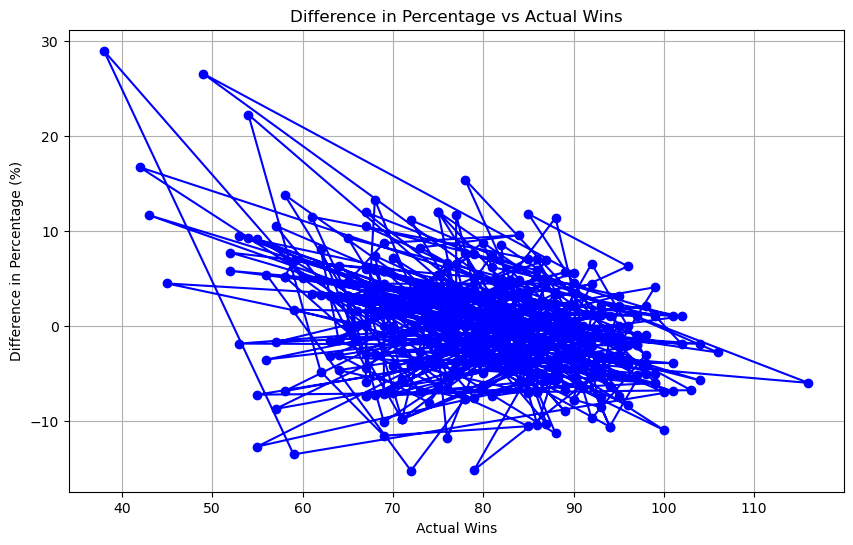

In [35]:
# Plot the percentage over the ID of the test set
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, difference_percentage, marker='o', linestyle='-', color='b')
plt.title('Difference in Percentage vs Actual Wins')
plt.xlabel('Actual Wins')
plt.ylabel('Difference in Percentage (%)')
plt.grid()
plt.show()

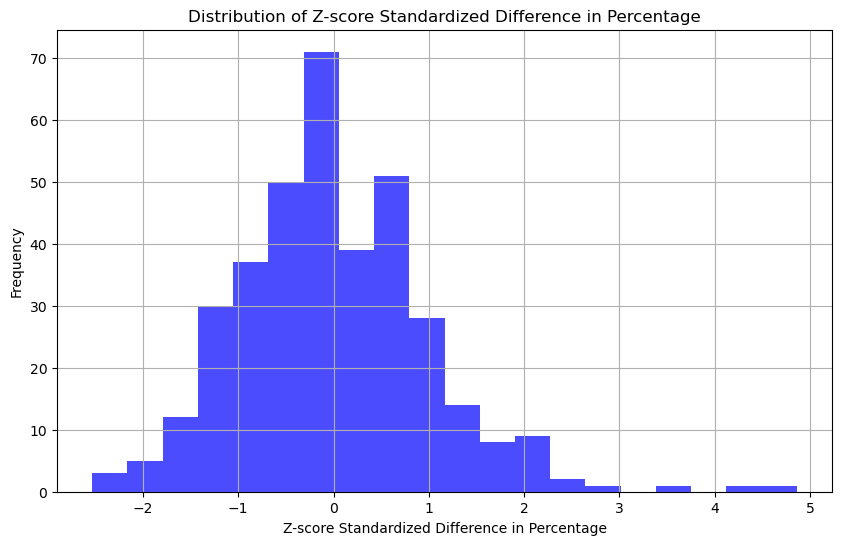

In [38]:
# Transform the percentage in Z-score standardization, and plot the distrbution of percentage
from scipy import stats
difference_percentage_zscore = stats.zscore(difference_percentage)
plt.figure(figsize=(10, 6))
plt.hist(difference_percentage_zscore, bins=20, color='b', alpha=0.7)
plt.title('Distribution of Z-score Standardized Difference in Percentage')
plt.xlabel('Z-score Standardized Difference in Percentage')
plt.ylabel('Frequency')
plt.grid()
plt.show()


In [ ]:
## 4. Train the model (fit())

In [ ]:
## 5. Evaluate the model by test data

In [ ]:
## 6. Check the regression matrix (mainly MSE and R2 score)

In [ ]:
## 7. Prepare the prediction dataset and make the prediction, use the same method to prepare dataset as the training dataset, and make the prediction by predict() method.

In [ ]:
## 8. Check the regression matrix of the prediction dataset (mainly MSE and R2 score)

In [ ]:
### Prediction will be carried out in the following sections

# Load the dataset from file ../assets/predict.csv and check the data
predict_data = pd.read_csv('../assets/predict.csv')
print(predict_data.head())
print(predict_data.info())
print(predict_data.describe())


In [41]:
# Construct the same features as the training dataset
predict_data['Run_Diff_1'] = predict_data['R'] - predict_data['RA']
predict_data['R_per_game_2'] = predict_data['R'] / predict_data['G']
predict_data['RA_per_game_3'] = predict_data['RA'] / predict_data['G']
predict_data['OPS_like_3'] = (predict_data['H'] + predict_data['BB'] + predict_data['HR']) / predict_data['AB'] 
predict_data['Power_Index_4'] = predict_data['HR'] + 0.5 * predict_data['2B'] + 0.8 * predict_data['3B']
predict_data['Plate_Discipline_Index_5'] = predict_data['BB'] / predict_data['SO']
predict_data['WHIP_like_6'] = (predict_data['HA'] + predict_data['BBA']) / predict_data['IPouts']
predict_data['K_BB_ratio_7'] = predict_data['SOA'] / predict_data['BBA']
predict_data['HR_allowed_rate_8'] = predict_data['HRA'] / predict_data['IPouts']
predict_data['Defence_10'] = predict_data['FP'] - (predict_data['E'] / predict_data['G'])

# Dropout the YearID, TeamID, ID, era-like features, YearLabel like features, DecadeLabel like features and Win Bins from the dataset, and set the target variable as 'W', and the rest of the features as the input features.
predict_X = predict_data[['Run_Diff_1', 'R_per_game_2', 'RA_per_game_3', 'OPS_like_3', 'Power_Index_4', 'Plate_Discipline_Index_5', 'WHIP_like_6', 'K_BB_ratio_7', 'HR_allowed_rate_8', 'Defence_10']]
#predict_y = predict_data['W']


In [42]:
# Use the trained Linear Regression model to make the prediction on the predict dataset
predict_y_pred_linear = linear_model.predict(predict_X)
print('Predicted values for the predict dataset:', predict_y_pred_linear.astype(int)) 

Predicted values for the predict dataset: [ 71  72  79  89  97  93  80  86  75  83  67  69  75  73  59  82  94  56
  88  82  82  84  48  90  71  80  66  94  92  61  73  69  74  87  65  61
  72  72  68  74  76  83  74  68  90  82  70  86  81  84  62  78  64  91
  81  90  72  73  96  70  89  77  75  59  69  63  82  72  82  67  86  84
  81  73  82  91  99  62  71  80  86  46  77  91  81  83  96  47  64  67
  67  84  88  85  96  75  72  93  84  73  86  84 105  76  82  90  82  60
  87  71  89  52  73  77  86  92  55  89  63  79  84  91  63  80  99  69
  73  69  66  81  80  73  84  74  96  79  86  81  78  76  88  72  70  81
  89  98  93  84  61  69  53  97  69  70  64  97  89  90  67  87  69  61
  63  92  80  97  51  81  86  67  58  49  62  86  78  93  73  65  89  72
  97  84  93  99  81  86  92  73  67  86  98  75  89  67  79  81  84 100
 103  89  69  65  70  83  95  87  76  78  59  69  70  93  96  90  62  79
  69  72  90  77  97  76  86  86  74  99  77  43  77  78  79  75  84  93
  78  80 

In [44]:
# Store the predicted values in a new csv file named predict_results.csv, with two columns: ID and Predicted_Wins, where ID is the ID column in the predict dataset, and Predicted_Wins is the predicted values for the predict dataset.
predict_results = pd.DataFrame({'ID': predict_data['ID'], 'Predicted_Wins': predict_y_pred_linear.astype(int)})
predict_results.to_csv('predict_results.csv', index=False)  

predict_results



,ID,Predicted_Wins
0,1756,71
1,1282,72
2,351,79
3,421,89
4,57,97
...,...,...
448,651,70
449,9,67
450,1518,100
451,2101,83


In [2]:
# Generate a synthetic regression dataset with 1000 samples and 20 features, 
# split it into 80% training and 20% testing sets, 

X, y = make_regression(n_samples=1000, n_features=20, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train a Linear Regression model on the training data.

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

LinearRegression()

In [3]:
# Generate predictions on the test set using the trained linear model
# and calculate the Mean Squared Error (MSE) to evaluate performance.

linear_preds = linear_reg.predict(X_test)
linear_mse = mean_squared_error(y_test, linear_preds)

print(f'Linear MSE: {linear_mse}')

Linear MSE: 4.4963065918746146e-26


In [4]:
# calculate the R-squared (R²) score to assess the proportion of variance in the dependent variable that is predictable from the independent variables.
linear_r2 = linear_reg.score(X_test, y_test)
print(f'Linear R²: {linear_r2}')

Linear R²: 1.0


# Model2: Redge Regression

In [5]:
# Initialize a Ridge regression model with regularization strength (alpha) of 1.0
# and fit it to the training data.

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)

Ridge()

In [6]:
# Generate predictions on the test set using the trained Ridge model
# and calculate the Mean Squared Error (MSE).

ridge_preds = ridge_reg.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_preds)

print(f'Ridge MSE: {ridge_mse}')

Ridge MSE: 0.0826756347545555


In [7]:
# Initialize a Lasso regression model with alpha=0.1, train it on the
# training set, make predictions on the test set, and compute the MSE.

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)

lasso_preds = lasso_reg.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_preds)

print(f'Lasso MSE: {lasso_mse}')

Lasso MSE: 0.09972349965638347


Logistic Regression model in `sklearn` already has regularization built-in. The default is `L2 (Ridge)`.

In [8]:
# Generate a binary classification dataset with 1000 samples and 20 features,
# split it into training and testing sets

X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train a Logistic Regression model with L2 regularization (C=1.0) on the training data.

log_ridge_reg = LogisticRegression(C=1.0)
log_ridge_reg.fit(X_train, y_train)

LogisticRegression()

In [9]:
# Generate predictions on the test set and evaluate the model's performance
# using a confusion matrix, accuracy, precision, recall, and F1 score.

y_pred = log_ridge_reg.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [10]:
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Confusion Matrix:
[[ 90   3]
 [  4 103]]
Accuracy: 0.96
Precision: 0.97
Recall: 0.96
F1 Score: 0.97


In [11]:
# Train a Logistic Regression model with L1 regularization (Lasso) to encourage feature sparsity.
# The 'saga' solver is used as it supports L1 penalties,

log_lasso_reg = LogisticRegression(C=1.0, penalty='l1', solver='saga', max_iter=10000)
log_lasso_reg.fit(X_train, y_train)

LogisticRegression(max_iter=10000, penalty='l1', solver='saga')

In [12]:
# Generate predictions on the test set and evaluate the model's performance
# using a confusion matrix, accuracy, precision, recall, and F1 score.

y_pred = log_lasso_reg.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [13]:
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Confusion Matrix:
[[ 90   3]
 [  4 103]]
Accuracy: 0.96
Precision: 0.97
Recall: 0.96
F1 Score: 0.97


In [15]:
# Train a Logistic Regression model with Elastic Net regularization, which combines L1 and L2 penalties.

log_enet_reg = LogisticRegression(penalty='elasticnet', solver='saga', C=1, l1_ratio=0.5, max_iter=10000)
log_enet_reg.fit(X_train, y_train)

LogisticRegression(C=1, l1_ratio=0.5, max_iter=10000, penalty='elasticnet',
                   solver='saga')

In [16]:
# Generate predictions on the test set and evaluate the model's performance
# using a confusion matrix, accuracy, precision, recall, and F1 score.

y_pred = log_enet_reg.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [17]:
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Confusion Matrix:
[[ 90   3]
 [  4 103]]
Accuracy: 0.96
Precision: 0.97
Recall: 0.96
F1 Score: 0.97


## Hyperparameter Tuning (Self-Study)

The regularization parameter ($\alpha$) and L1 ratio ($\rho$) are examples of **hyperparameters**. In machine learning, models have parameters that are learned from the data and hyperparameters that are set by the practitioner. Hyperparameter tuning is the process of finding the optimal combination of hyperparameters that yields the best performance. **Cross-validation** and **grid search** are two techniques used for this purpose.

### Cross-Validation

Cross-validation is a resampling procedure used to evaluate machine learning models on a limited data sample. Cross-validation involves partitioning the data into subsets, training the model on some subsets, and validating it on the remaining subsets. This process is repeated multiple times, and the results are averaged to estimate the model's performance. 

The goal is to assess how the predictions of a model will generalize to an independent dataset, which is identical to the purpose of train-test split which we have been doing thus far.

The train-test split is a simple method to divide your dataset into two parts: one for training the model and the other for testing it. However it has the following disadvantages if we use it for hyperparamters tuning:

- The evaluation may depend on how the data is split.
- The test score can vary significantly based on which data points end up in the training set and which in the test set.
- Less effective use of data, especially in cases where the amount of training data is limited.

Cross-validation has the following advantages when it comes to hyperparameters tuning:

- More reliable estimate of out-of-sample performance due to multiple rounds of splitting.
- Makes better use of data as each data point gets to be in a test set exactly once and in a training set K-1 times.

**Types of Cross-Validation**

![kfoldcv](../assets/kfold-cv.png)
- **K-Fold Cross-Validation**: The dataset is divided into K equal folds. Each fold acts as the validation set 1 time and acts as the training set K-1 times. The average performance metric across all K trials is used.
- **Leave-One-Out Cross-Validation**: A special case of K-Fold Cross-Validation where K is equal to the number of data points in the dataset.
- **Stratified K-Fold Cross-Validation**: Similar to K-Fold but preserves the percentage of samples for each class.

### Grid Search
![grid-random-search](../assets/grid-random-search.png)

Grid search is a brute force method to estimate the best hyperparameters. A grid of hyperparameter combinations is created, and the model is evaluated for each combination using cross-validation.

**Process**

1. Define the hyperparameter grid.
2. Use cross-validation to evaluate each combination of hyperparameters.
3. Select the combination that yields the best performance.

### Random Search

Random search is an alternative to grid search. Instead of trying out every possible combination, it samples a random subset of parameter combinations.

**Advantages**

- Can be faster than grid search when dealing with a large hyperparameter space.
- Can sometimes find a better combination of hyperparameters by exploring a wider range of values.

**Process**

1. Define a search space as a bounded domain of hyperparameter values.
2. Randomly sample combinations of hyperparameters from this domain.
3. Perform cross-validation for each combination.
4. Select the combination that yields the best validation score.

